# ENEL 441 Lab 2 - Prelab
# Closing The Loop

In this prelab you will:
1. Learn about the difference between the open loop poles and the closed loop poles.
2. Learn about the root locus plot.

This will help make the lab a better learning experience. 

# Part 1 - Modelling The Lab Equipment

# Diagram of the lab equipment

![motor Diagram](motorDiagram.JPG "Motor Diagram")

In general, the torque generated by a DC motor is proportional to the armature current and the strength of the magnetic field. In this example we will assume that the magnetic field is constant and, therefore, that the motor torque is proportional to only the armature current $i$ by a constant factor $K_t$ as shown in the equation below. This is referred to as an armature-controlled motor.

$$  T = K_{t} i$$

The back emf, $e$, is proportional to the angular velocity of the shaft by a constant factor $K_e$.

$$  e = K_{e} \dot{\theta}$$

The motor torque and back emf constants are equal, that is, $K_t = K_e$; therefore, we will use $K$ to represent both the motor torque constant and the back emf constant.

Torque due to friction in the bearings is 
$$
T_f = b \omega
$$
where $b$ is a constant, and $\omega$ is angular velocity.

From the figure above, we can derive the following governing equations. From Newton's 2nd law:

$$
\begin{align*}
\sum T &= J \alpha  \\
Ki - b \frac{d\theta}{dt} = J \frac{d^2 \theta}{dt^2} 
\end{align*}
$$

From the electrical portion of the system we can use Kirchhoff's voltage law to obtain:

$$ L \frac{di}{dt} + Ri = V - K\dot{\theta}$$

# Question 1

From these two differential equations, determine the transfer function of the system. Denote it $P(s)$. In this case we have armature voltage as the input, and rotational speed of the shaft as the output. 

$$Ki-b\omega=J\dot\omega$$

$$KI(s)-b\Omega(s)=Js\Omega(s)$$

$$LsI(s)+RI(s)=V-K\Omega(s)$$

$$I(s)=\frac{V-K\Omega(s)}{Ls+R}$$

$$K\frac{V-K\Omega(s)}{Ls+R}-b\Omega(s)=Js\Omega(s)$$

$$KV=K^2\Omega(s)+(Ls+R)(Js\Omega(s)+b\Omega(s))$$

$$\frac{\Omega(s)}{V(s)}=\frac{K}{K^2+(Ls+R)(Js+b)}$$

$$\frac{\Omega(s)}{V(s)}=\frac{K}{K^2+LJs^2+(Lb+RJ)s+Rb}$$

$$\frac{\Omega(s)}{V(s)}=\frac{K}{LJs^2+(Lb+RJ)s+(Rb+K^2)}$$

# Question 2

Make a Bode plot of $P(s)$ (the transfer function you derived in Question 1). Complete the following code.

The transfer function of the motor is: <TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

             0.01
  ---------------------------
  0.005 s^2 + 0.06 s + 0.1001
The poles of the motor are: [-9.99749922+0.j -2.00250078+0.j]


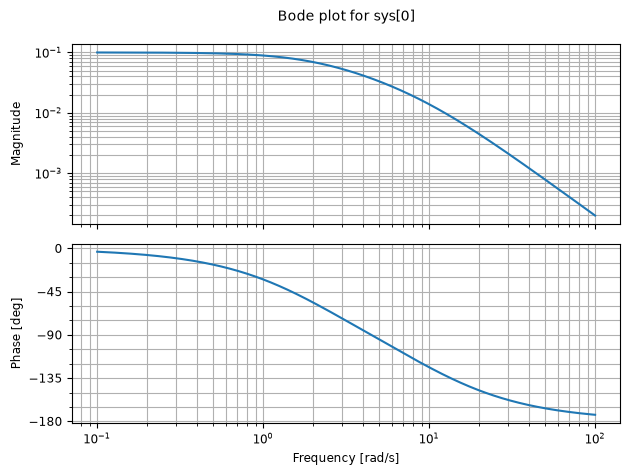

In [1]:
import control as ct
import numpy as np

J = 0.01
b = 0.1
K = 0.01
R = 1
L = 0.5

num = [K]
den = [L*J,L*b+R*J,R*b+K**2]

P_motor = ct.tf(num,den)
print('The transfer function of the motor is:', P_motor)

out = ct.bode_plot(P_motor)

open_loop_poles = P_motor.poles()

print('The poles of the motor are:', open_loop_poles)

# Question 3
Consider the closed loop diagram shown below.

![closed loop](simpleClosedLoop.png "closed loop")

In this case $P$ is the open loop transfer function of the 2 disk system, and $C$ is the controller. In this lab we will be studying proportional controllers, so the transfer function for the controller is $C(s) = K$. The so-called *closed loop transfer function* is the transfer function from $r$ to $y$. 

Write an expression for the closed loop transfer function (the transfer function from $r$ to $y$). This transfer function will be a function of $P$ and $C$. 

Hint: Start with $Y(s) = P(s) U(s)$. Now substitute an expression for $U(s)$ You can determine the expression for $U(s)$ from the figure above. Trace the signals.

$$Y(s)=P(s)U(s)$$

$$U(s)=C(s)[R(s)-Y(s)]$$

$$Y(s)=P(s)C(s)[R(s)-Y(s)]$$

$$Y(s)+P(s)C(s)Y(s)=P(s)C(s)R(s)$$

$$\frac{Y(s)}{R(s)}=\frac{P(s)C(s)}{1+P(s)C(s)}$$

# Question 4

Implement your expression for the closed-loop transfer function in Python. Let $K$ be a variable that you can adjust. Complete the following code snippet.

In [2]:
# transfer function for the controller
K = 1  # can change this number
C = ct.tf([K],[1])

# closed loop transfer function 
# write your code here. Let T be the closed loop transfer function
T = P_motor*C/(1+P_motor*C)



T = ct.minreal(T,verbose=False) # the minreal command removes pole/zero cancellations.

print('The closed loop transfer function is:', T)
print('The poles of the closed loop transfer function are:', T.poles() )


The closed loop transfer function is: <TransferFunction>: sys[8]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          2
  ------------------
  s^2 + 12 s + 22.02
The poles of the closed loop transfer function are: [-9.73898382+0.j -2.26101618+0.j]


# Question 4

Are the closed loop poles the same as the open loop poles? (Yes/No)

No, the closed loop poles are not the same as the open loop poles. The poles of the closed loop transfer function are affected by the feedback.

# Question 5

The amazing thing is that the closed-loop transfer function depends on the gain $K$. This means that we can change the poles of the closed loop system, by changing the gain of the controller! This is cool, because we cannot change the open loop poles (they are determined by the physics of the system). 

Calculate the closed loop poles for many different values of $K$, the gain of the proportional controller. Make an s-plane plot of how the poles change as $K$ changes. In other words, vary $K$ from $0.001$ to $10$ and calculate the closed-loop poles for each value of $K$. Store the closed loop poles in a vector. Plot the closed loop poles on the plane of complex numbers (i.e. the s-plane). 



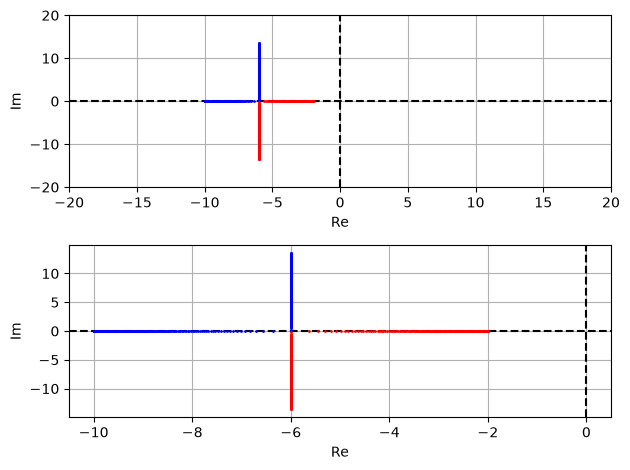

In [24]:
import matplotlib.pyplot as plt

N = 1000
K_vec = np.logspace(-3,2,N)

poles_vec = np.empty((N,2),dtype=complex)
ii = 0
for K in K_vec:
    C = ct.tf([K],[1])
    T = P_motor*C/(1+P_motor*C)    ## enter your expression here
   
    poles_vec[ii] = ct.minreal(T,verbose=False).poles()
    ii += 1

## make your plot here
fig, axs = plt.subplots(2,1)
axs[0].axhline(0, color='black', linestyle='--')
axs[0].axvline(0, color='black', linestyle='--')
axs[0].set_xlim(-20,20)
axs[0].set_ylim(-20,20)
axs[0].plot(np.real(poles_vec[:, 0]), np.imag(poles_vec[:, 0]), 'b.', markersize=2)
axs[0].plot(np.real(poles_vec[:, 1]), np.imag(poles_vec[:, 1]), 'r.', markersize=2)
axs[0].grid(True)
axs[0].set_xlabel("Re")
axs[0].set_ylabel("Im")


axs[1].axhline(0, color='black', linestyle='--')
axs[1].axvline(0, color='black', linestyle='--')
axs[1].plot(np.real(poles_vec[:, 0]), np.imag(poles_vec[:, 0]), 'b.', markersize=2)
axs[1].plot(np.real(poles_vec[:, 1]), np.imag(poles_vec[:, 1]), 'r.', markersize=2)
axs[1].grid(True)
axs[1].set_xlabel("Re")
axs[1].set_ylabel("Im")
plt.tight_layout()
plt.show()

# Question 6

Using the plot above to answer the following questions.
1. Are there values of $K$ for which the system is unstable? If so, then is it stable for big values of $K$ or small values of $K$? No, all the poles are left of the y-axis, meaning it is stable for all $K$ used to generate the plot.
2. Is the open loop system unstable? (Yes/No)
No, the open loop system is stable.

# Arduino IDE

In lab 2 you will be uploading code onto the Arduino. So at least one person in your group needs to install the Arduino IDE. Please do this ahead of time so that you don't spend a bunch of time in the lab trying to set up the Arduino IDE.

# End of Pre-Lab